In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pygom import Event, Transition, SimulateOde
import sys
sys.path.append("C:/Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src")

from simulation.stochastic.solve_stochastic import solve_stochastic

from simulation.deterministic.solve_deterministic import solve_deterministic

In [9]:
N = 10000
R0 = 1.5
gamma = 1 / 4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']
# states = [('S', (0, 100)), ('I', (0, 1)), ('R', (0, None))]

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

transition_names = ['new_infections', 'new_recoveries']

event_list = [event_infection, event_recovery]
model = SimulateOde(state=states, param=params, event=event_list)
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

In [10]:
i0 = 10
y0 = np.array([N-i0, i0, 0])

ylims = [(0, N), (0, N), (0, N)]
ylims = np.asarray(ylims, dtype=object)  # because we have None
mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in ylims])
maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in ylims])

stoichiometry_matrix = model.state_change_matrix(y0, 0)
event_rates = model.event_rate_vector.T
f_mu = model.transition_mean.T
f_var= model.transition_variance.T
ode = model.ode.T
jac_state = model.jacobian.T
jac_rates = model.rates_jacobian.T

n_state, n_event = stoichiometry_matrix.shape

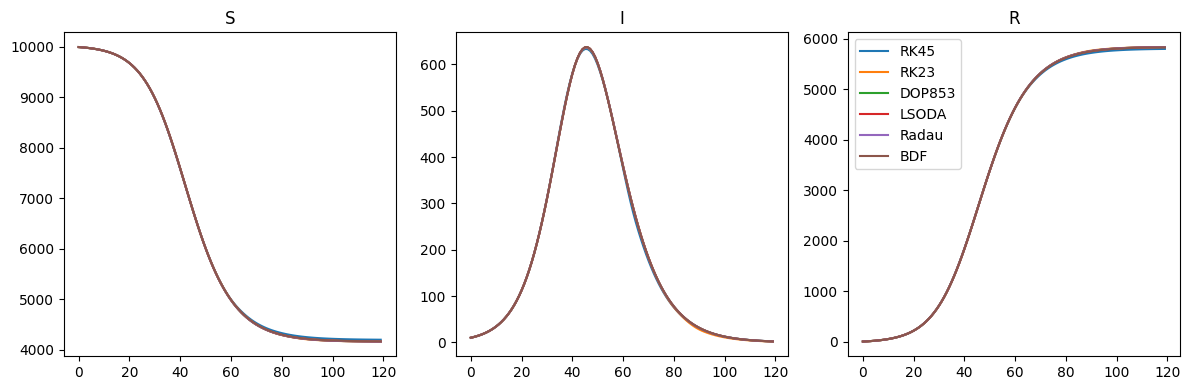

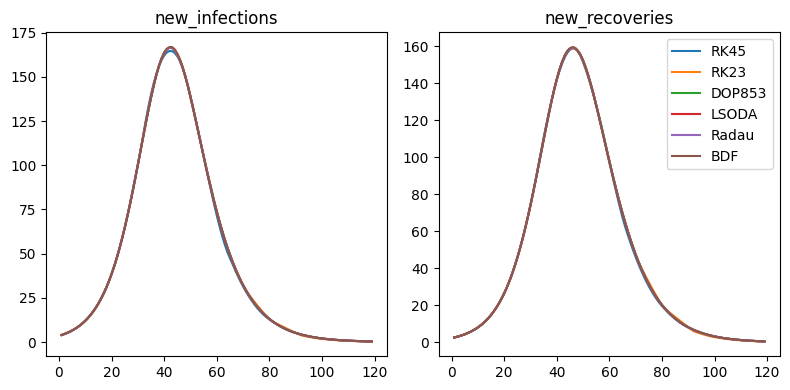

In [11]:
t_span = (0, 120)
t_eval = np.arange(0, 120)

outs = {}

methods = ['RK45', 'RK23', 'DOP853']
for method in methods:
    out = solve_deterministic(
            ode,
            event_rates,
            n_state,
            n_event,
            t_span,
            y0,
            method=method,
            t_eval=t_eval)
    outs[method] = out

methods = ['LSODA', 'Radau', 'BDF']
for method in methods:
    out = solve_deterministic(
            ode,
            event_rates,
            n_state,
            n_event,
            t_span,
            y0,
            t_eval=t_eval,
            method=method,
            jac_events=jac_rates,
            jac_ode=jac_state)
    outs[method] = out
    

fig, ax = plt.subplots(1, n_state, figsize = (12, 4))

for i in range(n_state):
    for method in outs.keys():
        out = outs[method]
        ax[i].plot(out.result.t, out.result.y[:, i], label=method)
        ax[i].set_title(states[i])
plt.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, n_event, figsize = (8, 4))

for i in range(n_event):
    for method in outs.keys():
        out = outs[method]
        ax[i].plot(out.result.t[1:], out.result.event_counts[:, i], label=method)
        ax[i].set_title(transition_names[i])
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
prob_refiner = {
    'refiner':'prob',
    'refiner_opts': {"max_retries":20, "acceptable_prob_misstep":0.1, "factor_min": 0.01, "factor_max": 0.4}
}
no_refiner = {
    'refiner':'none'
}

refiners = [prob_refiner, no_refiner]

checkers = [{'checker': 'forbidden_reaction'},
            {'checker': 'forbidden_state'}]

{'tau': 0.1, 'refiner': 'prob', 'refiner_opts': {'max_retries': 20, 'acceptable_prob_misstep': 0.1, 'factor_min': 0.01, 'factor_max': 0.4}, 'checker': 'forbidden_reaction'}


C:\Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src\simulation\post_processing.py:130: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  density = np.divide(event_counts[:, i], dt, where=dt>0)


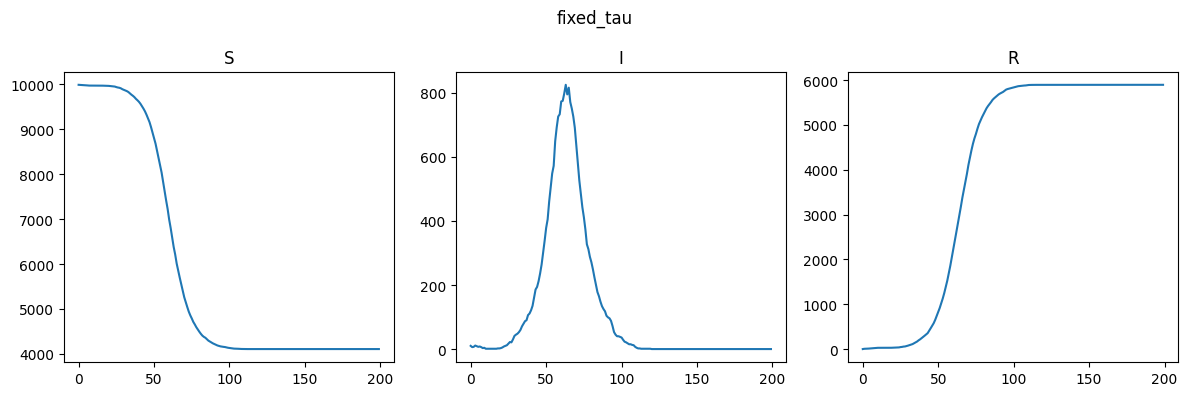

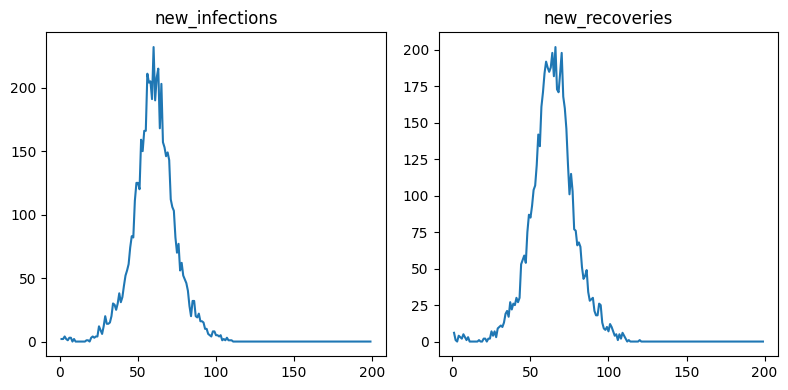

{'tau': 0.1, 'refiner': 'none', 'checker': 'forbidden_reaction'}


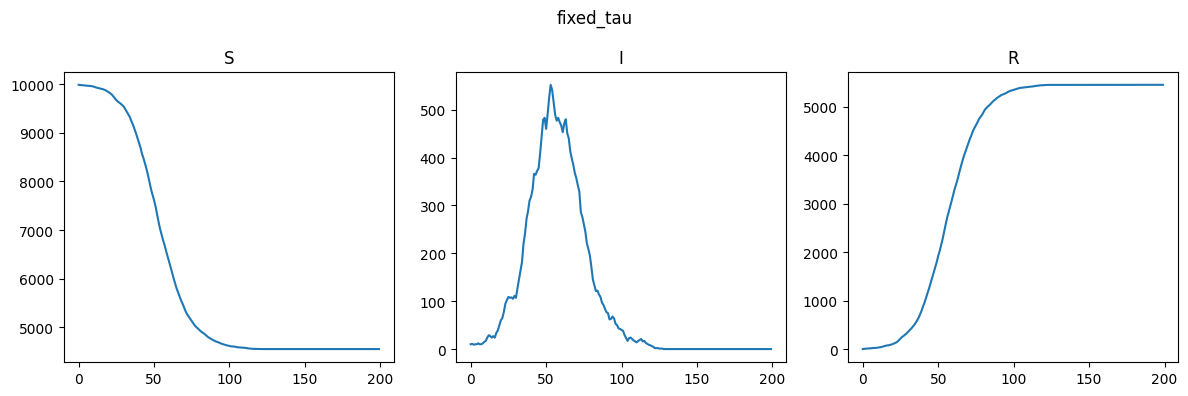

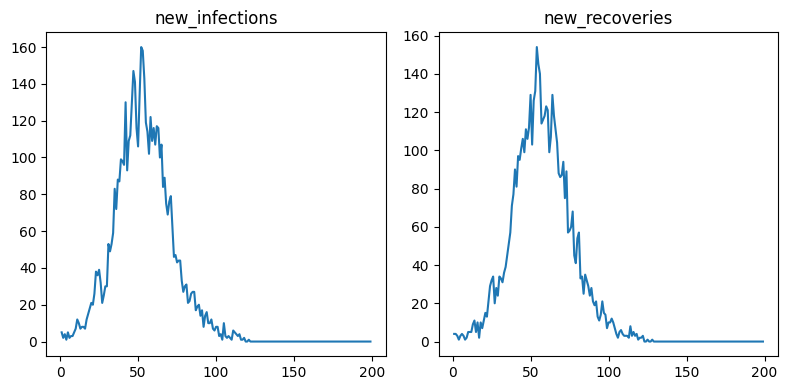

{'tau': 0.1, 'refiner': 'prob', 'refiner_opts': {'max_retries': 20, 'acceptable_prob_misstep': 0.1, 'factor_min': 0.01, 'factor_max': 0.4}, 'checker': 'forbidden_state'}


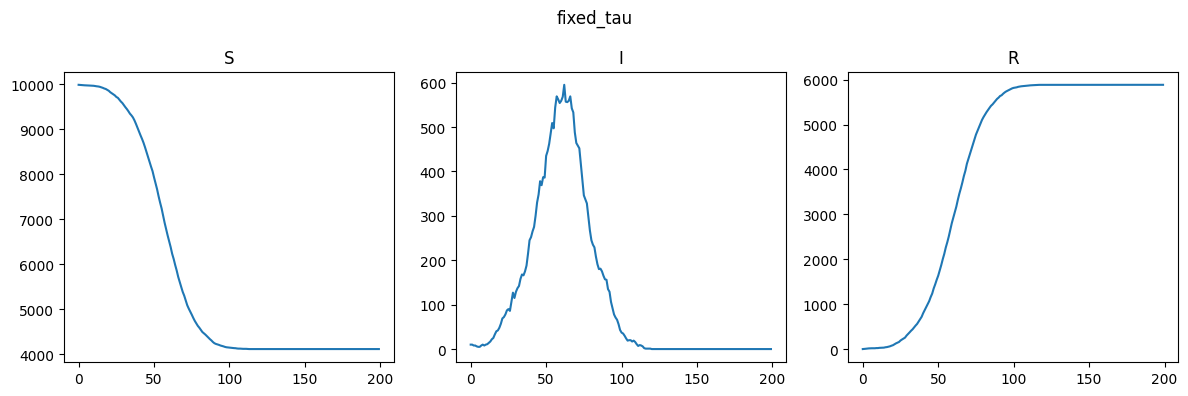

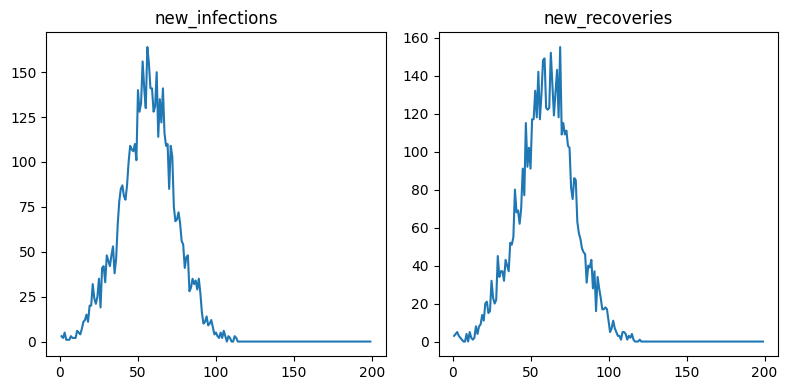

{'tau': 0.1, 'refiner': 'none', 'checker': 'forbidden_state'}


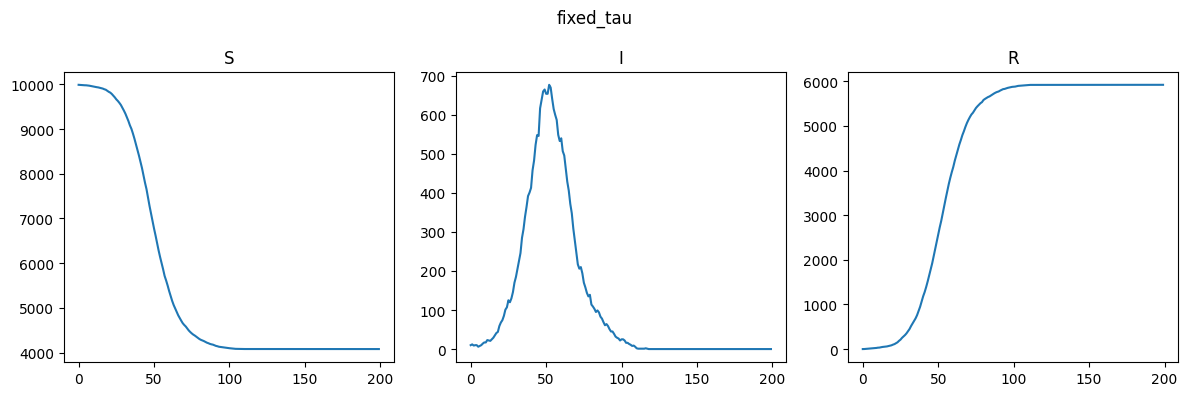

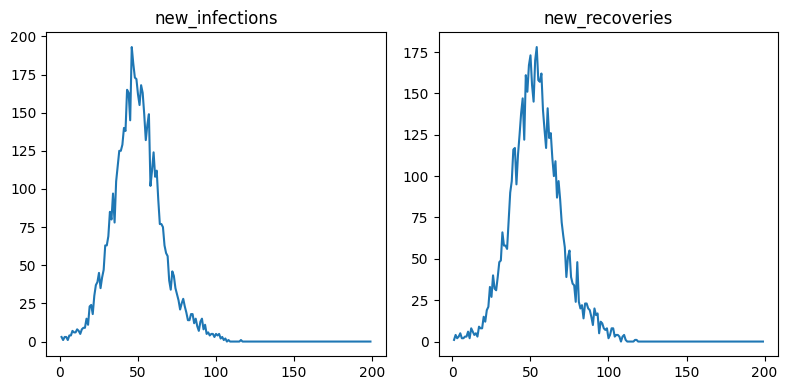

{'epsilon': 0.03, 'transition_mean_func': <bound method NumericMethod.T of <pygom.model.maths.transition_mean.TransitionMean object at 0x000001F44B99BFE0>>, 'transition_var_func': <bound method NumericMethod.T of <pygom.model.maths.transition_variance.TransitionVariance object at 0x000001F44B99B4D0>>, 'refiner': 'prob', 'refiner_opts': {'max_retries': 20, 'acceptable_prob_misstep': 0.1, 'factor_min': 0.01, 'factor_max': 0.4}, 'checker': 'forbidden_reaction'}


C:\Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 154.7603328491473
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


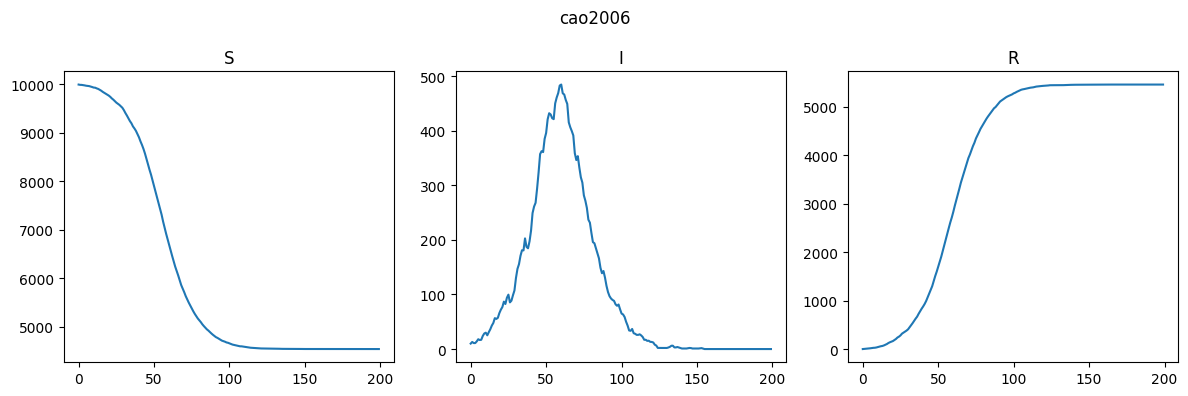

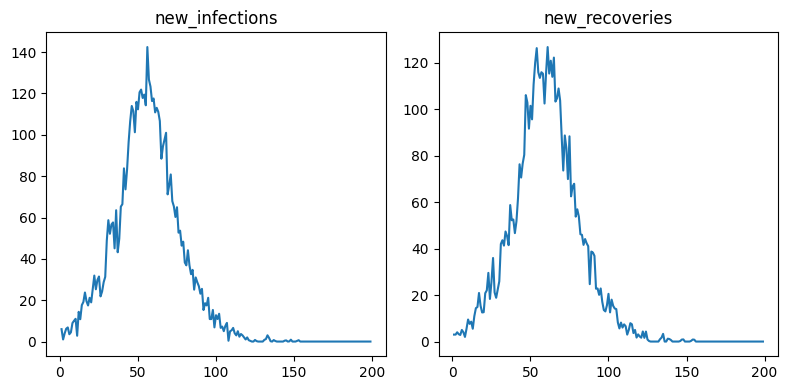

{'epsilon': 0.03, 'transition_mean_func': <bound method NumericMethod.T of <pygom.model.maths.transition_mean.TransitionMean object at 0x000001F44B99BFE0>>, 'transition_var_func': <bound method NumericMethod.T of <pygom.model.maths.transition_variance.TransitionVariance object at 0x000001F44B99B4D0>>, 'refiner': 'none', 'checker': 'forbidden_reaction'}


C:\Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 176.23642188250417
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


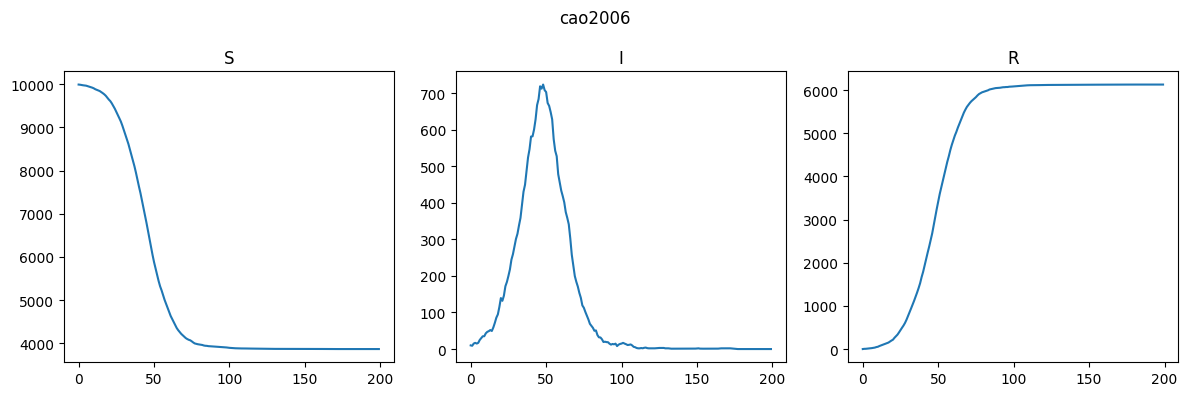

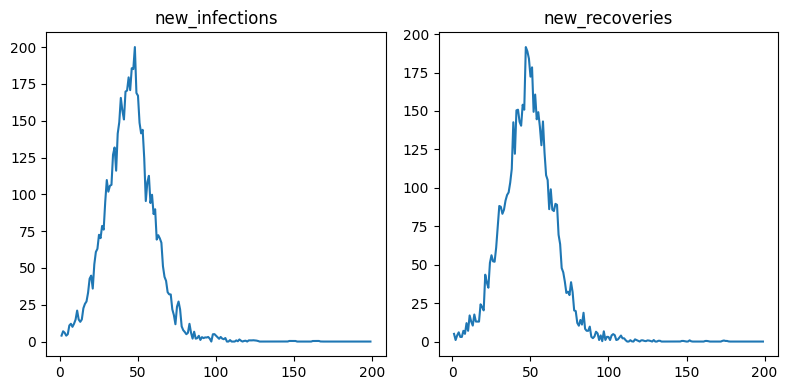

{'epsilon': 0.03, 'transition_mean_func': <bound method NumericMethod.T of <pygom.model.maths.transition_mean.TransitionMean object at 0x000001F44B99BFE0>>, 'transition_var_func': <bound method NumericMethod.T of <pygom.model.maths.transition_variance.TransitionVariance object at 0x000001F44B99B4D0>>, 'refiner': 'prob', 'refiner_opts': {'max_retries': 20, 'acceptable_prob_misstep': 0.1, 'factor_min': 0.01, 'factor_max': 0.4}, 'checker': 'forbidden_state'}


C:\Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 102.51673926351489
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


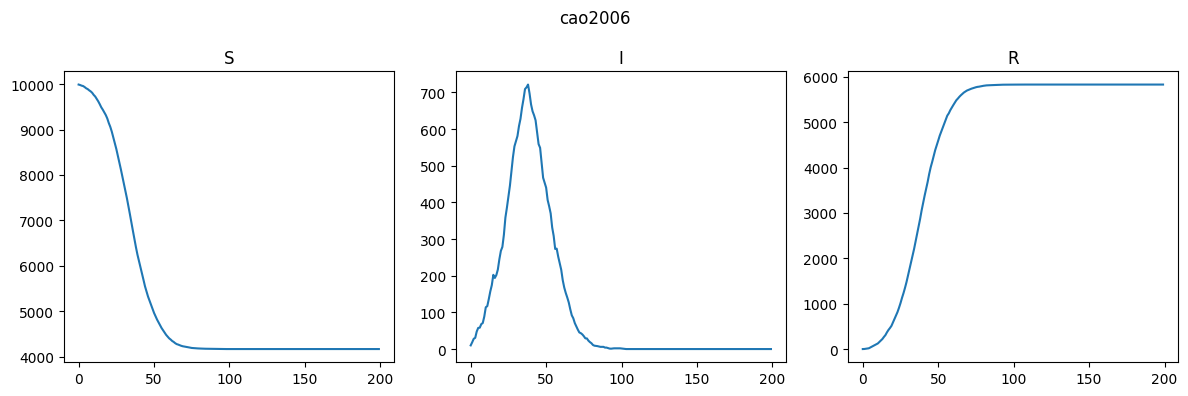

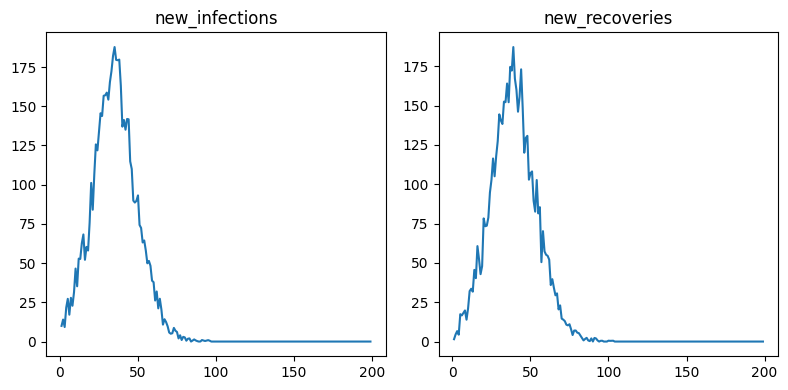

{'epsilon': 0.03, 'transition_mean_func': <bound method NumericMethod.T of <pygom.model.maths.transition_mean.TransitionMean object at 0x000001F44B99BFE0>>, 'transition_var_func': <bound method NumericMethod.T of <pygom.model.maths.transition_variance.TransitionVariance object at 0x000001F44B99B4D0>>, 'refiner': 'none', 'checker': 'forbidden_state'}


C:\Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 134.57013445620262
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


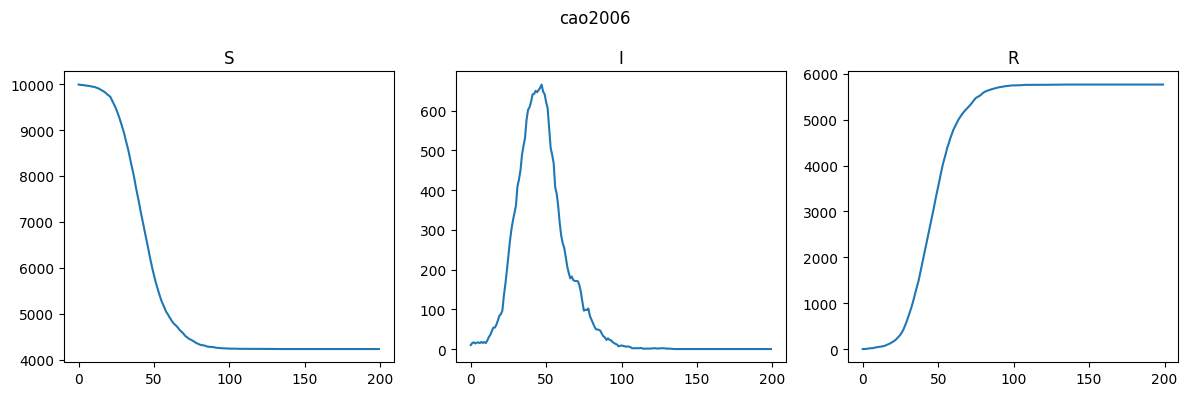

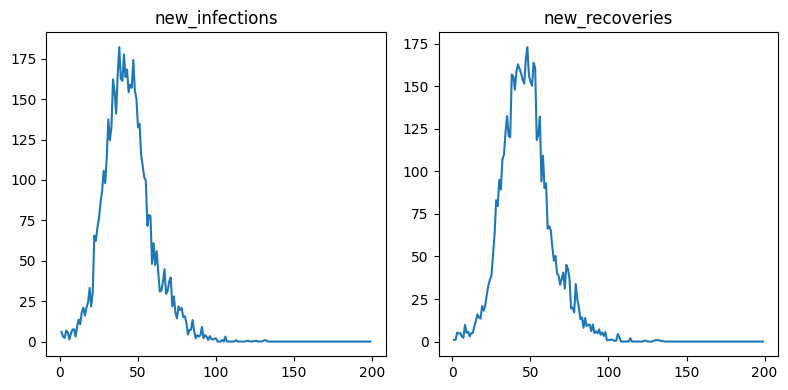

In [13]:

tau_methods = {
    'fixed_tau': {'tau': 0.1},
    'cao2006': {'epsilon': 0.03, 'transition_mean_func': f_mu, 'transition_var_func': f_var}
}

t_span = (0, 200)
t_eval = np.arange(0, 200)

for method, option in tau_methods.items():
    for checker in checkers:
        for refiner in refiners:
            options = option | (refiner | checker)
            print(options)

            out = solve_stochastic(
                event_rates=event_rates,
                stoichiometry_matrix=stoichiometry_matrix,
                t_span=t_span,
                t_eval=t_eval,
                y0=y0,
                y_min=mins,
                y_max=maxs,
                method=method,
                perf=True,
                **options
            )

            n_state = out.result.y.shape[1]

            fig, ax = plt.subplots(1, n_state, figsize = (12, 4))

            for i in range(n_state):
                ax[i].plot(out.result.t, out.result.y[:, i])
                ax[i].set_title(states[i])
            # plt.suptitle(f'{method}\n{out.diag}\n{out.performance}')
            plt.suptitle(f'{method}')
            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(1, n_event, figsize = (8, 4))

            for i in range(n_event):
                ax[i].plot(out.result.t[1:], out.result.event_counts[:, i])
                ax[i].set_title(transition_names[i])
            plt.tight_layout()
            plt.show()

<class 'numpy.int64'>


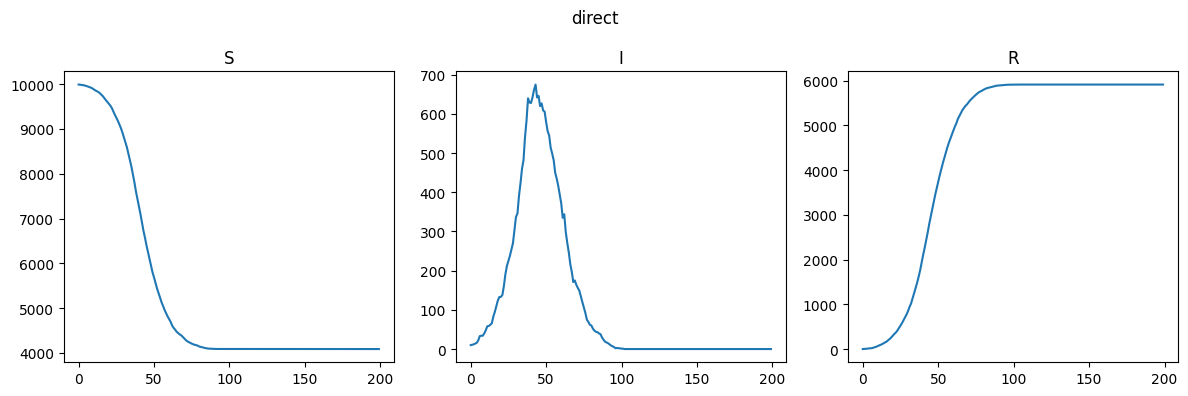

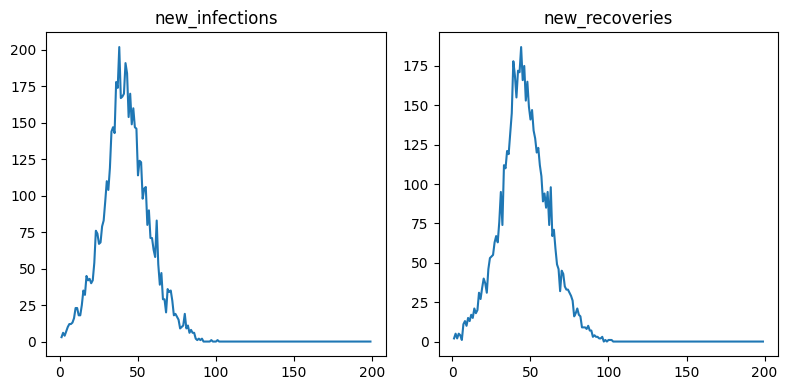

<class 'numpy.int64'>


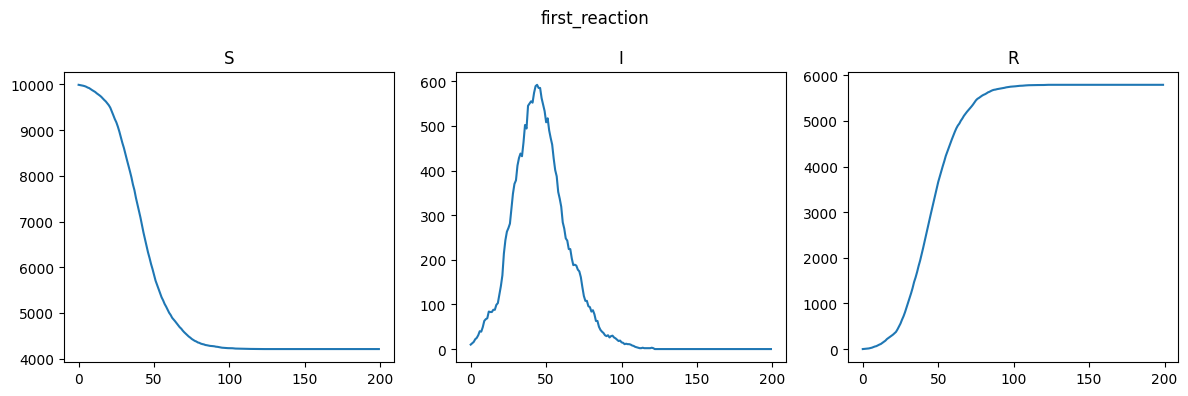

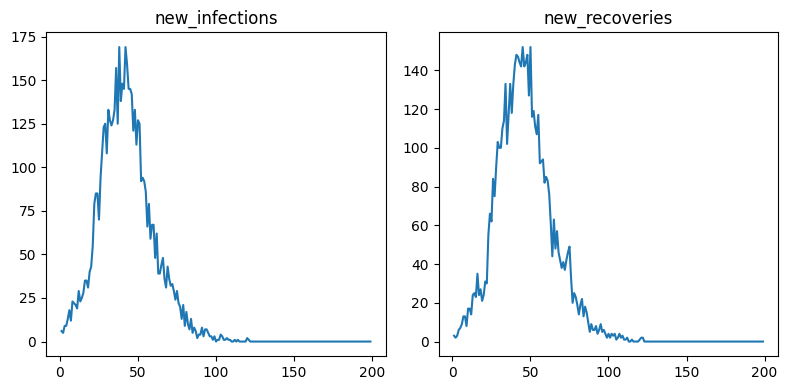

In [14]:
exact_methods = {
    'direct': {},
    'first_reaction': {}
}

for method, options in exact_methods.items():
    out = solve_stochastic(
        event_rates=event_rates,
        stoichiometry_matrix=stoichiometry_matrix,
        t_span=t_span,
        t_eval=t_eval,
        y0=y0,
        y_min=mins,
        y_max=maxs,
        method=method,
        perf=True,
        **options
    )

    print(type(out.result.y[0, 0]))

    n_state = out.result.y.shape[1]

    fig, ax = plt.subplots(1, n_state, figsize = (12, 4))

    for i in range(n_state):
        ax[i].plot(out.result.t, out.result.y[:, i])
        ax[i].set_title(states[i])
    # plt.suptitle(f'{method}\n{out.diag}\n{out.performance}')
    plt.suptitle(f'{method}')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, n_event, figsize = (8, 4))

    for i in range(n_event):
        ax[i].plot(out.result.t[1:], out.result.event_counts[:, i])
        ax[i].set_title(transition_names[i])
    plt.tight_layout()
    plt.show()
